# 0. Complex Graph Traversal Dataset Generation and Topology Analysis
## Empirical Characterization of Algorithmic DFS Traces and Underlying Graph Topologies

### Executive Summary & Educational Motivation
In neural algorithmic reasoning, understanding the structural and statistical properties of input data is essential for model design. When an algorithm explores an unknown graph using **Depth-First Search (DFS)**, the resulting sequential traversal trace embeds implicit information about node adjacencies, graph density, branching factors, and dead-end paths.

This notebook constructs a standardized procedural dataset of goal-terminated DFS traversal traces and provides a thorough empirical analysis of the underlying graph topologies. The dataset is saved directly to **Google Drive** (with automatic local fallback) so that it can be reused across different transformer architectures and experimental paradigms (such as One-Shot Non-Autoregressive vs. Step-by-Step Autoregressive models).

---

### Mathematical Problem Formulation

#### 1. Graph Generation and Adjacency Structure
Let $G = (V, E)$ be an undirected, unweighted connected graph with $N$ nodes ($20 \le N \le 35$), where node identifiers are randomly permuted from a fixed vocabulary $\mathcal{V}_{nodes} = \{0, 1, \dots, 39\}$.

#### 2. Goal-Terminated DFS Traversal Trace
A DFS agent starting at root node $s \in V$ explores $G$ until it discovers destination node $g \in V$. The search **terminates immediately** upon reaching $g$, yielding the trace:
$$T = [t_1, t_2, \dots, t_K]$$
where $t_1 = s$, $t_K = g$, $t_k \neq g$ for all $1 \le k < K$, and $30 \le K \le 50$. Each adjacent transition $(t_k, t_{k+1})$ represents either a forward exploration step along an edge $e \in E$ or a return step (backtracking to a parent node from a dead-end or fully explored branch).

#### 3. Node Backtraces and Induced Regressions
In a DFS traversal, when $t_k = t_{k-2}$, the transition represents a return/backtrack step from dead-end or sub-branch node $t_{k-1}$ back to parent node $t_k$. We define the **Node Backtrace Count** $B(v)$ as the number of times node $v$ induced a regression during traversal:
$$B(v) = \sum_{k=3}^K \mathbb{I}\big(t_k = t_{k-2} \text{ and } t_{k-1} = v\big)$$

#### 4. Shortest Path Target
The true shortest path $P^*$ between $s$ and $g$ in $G_T$ (the graph reconstructed from trace $T$) is represented as:
$$P^* = [p_1^*, p_2^*, \dots, p_M^*]$$
where $p_1^* = s$, $p_M^* = g$, and $10 \le M \le 20$.


In [1]:
# Cell 1: Environment Setup, Seeds, and Google Drive Path Configuration

import os
import random
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Ensure charts and data directories exist relative to repo root / working dir
if os.path.basename(os.getcwd()) == "graphs":
    os.makedirs("../charts", exist_ok=True)
    os.makedirs("charts", exist_ok=True)
    os.makedirs("data", exist_ok=True)
    LOCAL_DATA_DIR = "data"
else:
    os.makedirs("charts", exist_ok=True)
    os.makedirs("graphs/charts", exist_ok=True)
    os.makedirs("graphs/data", exist_ok=True)
    LOCAL_DATA_DIR = "graphs/data"

# Set PyTorch CPU thread count to 1 for reproducible, efficient single-core execution
torch.set_num_threads(1)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Google Drive Mount & Dataset Path Resolution
def setup_data_dir():
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        save_dir = "/content/drive/MyDrive/graph_data"
    except ImportError:
        save_dir = LOCAL_DATA_DIR

    os.makedirs(save_dir, exist_ok=True)
    print(f"Dataset path initialized: {save_dir}")
    return save_dir

DATA_DIR = setup_data_dir()
DATASET_PATH = os.path.join(DATA_DIR, "graph_dfs_dataset.pt")


Mounted at /content/drive
Dataset path initialized: /content/drive/MyDrive/graph_data


### Dataset Construction: Candidate-Filtered Goal-Terminated DFS Traces
To guarantee complex reasoning challenges with explicit dead-ends and multi-branch exploration:
1. **Goal-Terminated Traversal**: DFS stops **immediately** upon discovering the goal node $g$, so $g$ appears **exactly once** at the final position (`trace[-1] == g`).
2. **Hardened Target Length Bounds**:
   - DFS Trace Length $K$: $30 \le K \le 50$
   - Shortest Path Length $M$: $10 \le M \le 20$
3. **Node Backtraces & Induced Regressions**: Track how many times each node induced a backtrack/regression step.
4. **Randomized Token Order**: Node identifiers are randomly permuted across $\{0, 1, \dots, 39\}$ for every sample.


In [2]:
# Cell 2: Procedural Candidate Sampling, Filtering, and Node Backtrace Metrics

VOCAB_SIZE = 42
PAD_TOKEN = 40
STOP_TOKEN = 41
MAX_SRC_LEN = 50
MAX_TGT_LEN = 21

def generate_single_candidate(min_nodes=20, max_nodes=35, max_trace_len=50, min_trace_len=30, min_sp_len=10, max_sp_len=20):
    for attempt in range(100):
        n = random.randint(min_nodes, max_nodes)
        G = nx.random_labeled_tree(n)

        # Add random extra edges to create loops and alternate paths
        extra_edges = random.randint(2, 6)
        for _ in range(extra_edges):
            u, v = random.sample(range(n), 2)
            if u != v:
                G.add_edge(u, v)

        start = random.choice(range(n))
        goal = random.choice([v for v in range(n) if v != start])

        # Goal-terminated DFS traversal
        trace = []
        visited = set()
        goal_reached = False

        def dfs(u):
            nonlocal goal_reached
            if goal_reached:
                return
            trace.append(u)
            visited.add(u)

            if u == goal:
                goal_reached = True
                return

            neighbors = list(G.neighbors(u))
            random.shuffle(neighbors)
            for v in neighbors:
                if goal_reached:
                    return
                if v not in visited:
                    dfs(v)
                    if not goal_reached:
                        trace.append(u) # Backtracking step

        dfs(start)

        if not goal_reached or trace[-1] != goal or trace.count(goal) != 1:
            continue

        if not (min_trace_len <= len(trace) <= max_trace_len):
            continue

        # Reconstruct graph from trace
        G_trace = nx.Graph()
        for i in range(len(trace) - 1):
            G_trace.add_edge(trace[i], trace[i+1])

        if not nx.has_path(G_trace, start, goal):
            continue

        sp = nx.shortest_path(G_trace, source=start, target=goal)

        if min_sp_len <= len(sp) <= max_sp_len:
            # Backtrace metric calculation
            backtracks = 0
            node_backtraces = {node: 0 for node in G_trace.nodes()}
            for i in range(2, len(trace)):
                if trace[i] == trace[i-2]:
                    backtracks += 1
                    node_backtraces[trace[i-1]] += 1

            # Token permutation over vocabulary of 40 node IDs
            vocab = list(range(40))
            perm = random.sample(vocab, n)
            mapping = {i: perm[i] for i in range(n)}

            perm_trace = [mapping[x] for x in trace]
            perm_sp = [mapping[x] for x in sp]
            G_perm = nx.relabel_nodes(G_trace, mapping)
            perm_node_backtraces = {mapping[k]: v for k, v in node_backtraces.items() if k in mapping}

            return perm_trace, perm_sp, G_perm, mapping, backtracks, perm_node_backtraces

    return None

def generate_filtered_dataset(target_samples=4000):
    dataset = []
    attempts = 0
    max_attempts = target_samples * 10
    while len(dataset) < target_samples and attempts < max_attempts:
        sample = generate_single_candidate()
        attempts += 1
        if sample is not None:
            dataset.append(sample)
    return dataset

print("Generating 4,000 candidate-filtered complex graph DFS samples (src: 30-50, tgt: 10-20)...")
start_time = time.time()
raw_data = generate_filtered_dataset(4000)
print(f"Generated {len(raw_data)} samples in {time.time() - start_time:.2f} seconds.")

# Dataset Split: Train (3000), Val (500), Test (500)
train_raw = raw_data[:3000]
val_raw = raw_data[3000:3500]
test_raw = raw_data[3500:4000]

print(f"Splits constructed: Train={len(train_raw)}, Val={len(val_raw)}, Test={len(test_raw)}")


Generating 4,000 candidate-filtered complex graph DFS samples (src: 30-50, tgt: 10-20)...
Generated 4000 samples in 7.55 seconds.
Splits constructed: Train=3000, Val=500, Test=500


### Dataset Serialization to Drive
We serialize the raw processed dataset (including node traces, shortest path targets, NetworkX graph topologies, token mappings, and node backtrace metrics) using PyTorch `torch.save()`.


In [3]:
# Cell 3: Save Processed Dataset to Drive / Local Directory

dataset_payload = {
    'train': train_raw,
    'val': val_raw,
    'test': test_raw,
    'vocab_size': VOCAB_SIZE,
    'pad_token': PAD_TOKEN,
    'stop_token': STOP_TOKEN,
    'max_src_len': MAX_SRC_LEN,
    'max_tgt_len': MAX_TGT_LEN
}

torch.save(dataset_payload, DATASET_PATH)
file_size_mb = os.path.getsize(DATASET_PATH) / (1024 * 1024)
print(f"Dataset successfully saved to '{DATASET_PATH}' ({file_size_mb:.2f} MB).")


Dataset successfully saved to '/content/drive/MyDrive/graph_data/graph_dfs_dataset.pt' (4.63 MB).


### Empirical Analysis of Dataset & Graph Topologies
We compute key graph-theoretic, algorithmic trace, and node regression properties across the entire dataset:
1. **Node & Edge Statistics**: Node counts, edge counts, and average degree.
2. **DFS Trace & Shortest Path Bounds**: Sequence lengths ($30 \le K \le 50$, $10 \le M \le 20$).
3. **Node Backtraces & Induced Regressions**: Count of return steps ($t_k = t_{k-2}$) and max regressions induced by individual nodes.
4. **Path Compression Ratio**: $\eta = \text{Shortest Path Length } M / \text{DFS Trace Length } K$.


In [4]:
# Cell 4: Compute Comprehensive Graph Topological & Backtrace Statistics

degrees = []
node_counts = []
edge_counts = []
trace_lengths = []
sp_lengths = []
compression_ratios = []
backtrack_counts = []
max_regressions_per_node = []

for trace, sp, G, mapping, backtracks, node_backtraces in raw_data:
    node_counts.append(G.number_of_nodes())
    edge_counts.append(G.number_of_edges())

    deg_list = [d for _, d in G.degree()]
    degrees.extend(deg_list)

    K = len(trace)
    M = len(sp)
    trace_lengths.append(K)
    sp_lengths.append(M)
    compression_ratios.append(M / K)
    backtrack_counts.append(backtracks)

    max_reg = max(node_backtraces.values()) if node_backtraces else 0
    max_regressions_per_node.append(max_reg)

print("=" * 70)
print("             HARDENED GRAPH & DFS TRAVERSAL DATASET STATISTICS")
print("=" * 70)
print(f"{'Metric':<38} | {'Mean ± Std':<15} | {'[Min, Max]':<10}")
print("-" * 70)
print(f"{'Node Count (N)':<38} | {np.mean(node_counts):.2f} ± {np.std(node_counts):.2f}   | [{np.min(node_counts)}, {np.max(node_counts)}]")
print(f"{'Edge Count (|E|)':<38} | {np.mean(edge_counts):.2f} ± {np.std(edge_counts):.2f}   | [{np.min(edge_counts)}, {np.max(edge_counts)}]")
print(f"{'Average Node Degree (<k>)':<38} | {np.mean(degrees):.2f} ± {np.std(degrees):.2f}   | [{np.min(degrees)}, {np.max(degrees)}]")
print(f"{'DFS Trace Length (K) [Target 30-50]':<38} | {np.mean(trace_lengths):.2f} ± {np.std(trace_lengths):.2f}   | [{np.min(trace_lengths)}, {np.max(trace_lengths)}]")
print(f"{'Shortest Path Length (M) [Target 10-20]':<38} | {np.mean(sp_lengths):.2f} ± {np.std(sp_lengths):.2f}   | [{np.min(sp_lengths)}, {np.max(sp_lengths)}]")
print(f"{'Compression Ratio (M / K)':<38} | {np.mean(compression_ratios):.3f} ± {np.std(compression_ratios):.3f} | [{np.min(compression_ratios):.2f}, {np.max(compression_ratios):.2f}]")
print(f"{'Total Backtracks per Trace':<38} | {np.mean(backtrack_counts):.2f} ± {np.std(backtrack_counts):.2f}   | [{np.min(backtrack_counts)}, {np.max(backtrack_counts)}]")
print(f"{'Max Induced Regressions per Node':<38} | {np.mean(max_regressions_per_node):.2f} ± {np.std(max_regressions_per_node):.2f}   | [{np.min(max_regressions_per_node)}, {np.max(max_regressions_per_node)}]")
print("=" * 70)


             HARDENED GRAPH & DFS TRAVERSAL DATASET STATISTICS
Metric                                 | Mean ± Std      | [Min, Max]
----------------------------------------------------------------------
Node Count (N)                         | 24.86 ± 2.87   | [20, 34]
Edge Count (|E|)                       | 23.86 ± 2.87   | [19, 33]
Average Node Degree (<k>)              | 1.92 ± 0.80   | [1, 7]
DFS Trace Length (K) [Target 30-50]    | 36.88 ± 5.47   | [30, 50]
Shortest Path Length (M) [Target 10-20] | 12.84 ± 2.49   | [10, 20]
Compression Ratio (M / K)              | 0.357 ± 0.090 | [0.20, 0.67]
Total Backtracks per Trace             | 6.00 ± 1.70   | [1, 13]
Max Induced Regressions per Node       | 1.00 ± 0.00   | [1, 1]


### Publication-Quality Analytical Plots
We generate and save comprehensive visualizations characterizing graph topologies and DFS traces:
1. **Degree & Length Distributions**: Histograms of node degrees, DFS trace lengths ($30 \le K \le 50$), and shortest path lengths ($10 \le M \le 20$) (`charts/graph_topology_distributions.png`).
2. **Trace Efficiency & Backtracking Scatter**: Efficiency vs. total backtracks (`charts/graph_dfs_compression_analysis.png`).
3. **Sample Graph Layouts & Original Input Sequences**: Rendering the NetworkX layout overlaid with the original input sequence both as text and in the visual chart.


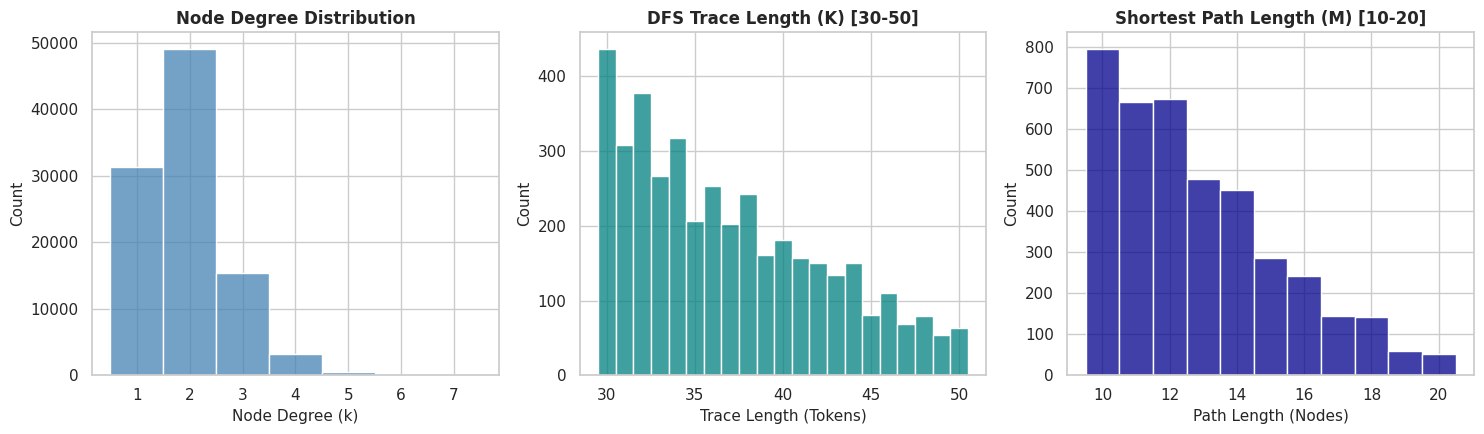

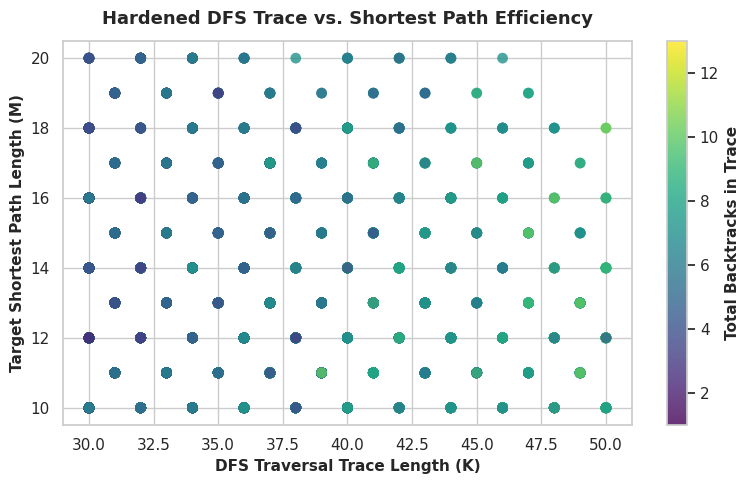

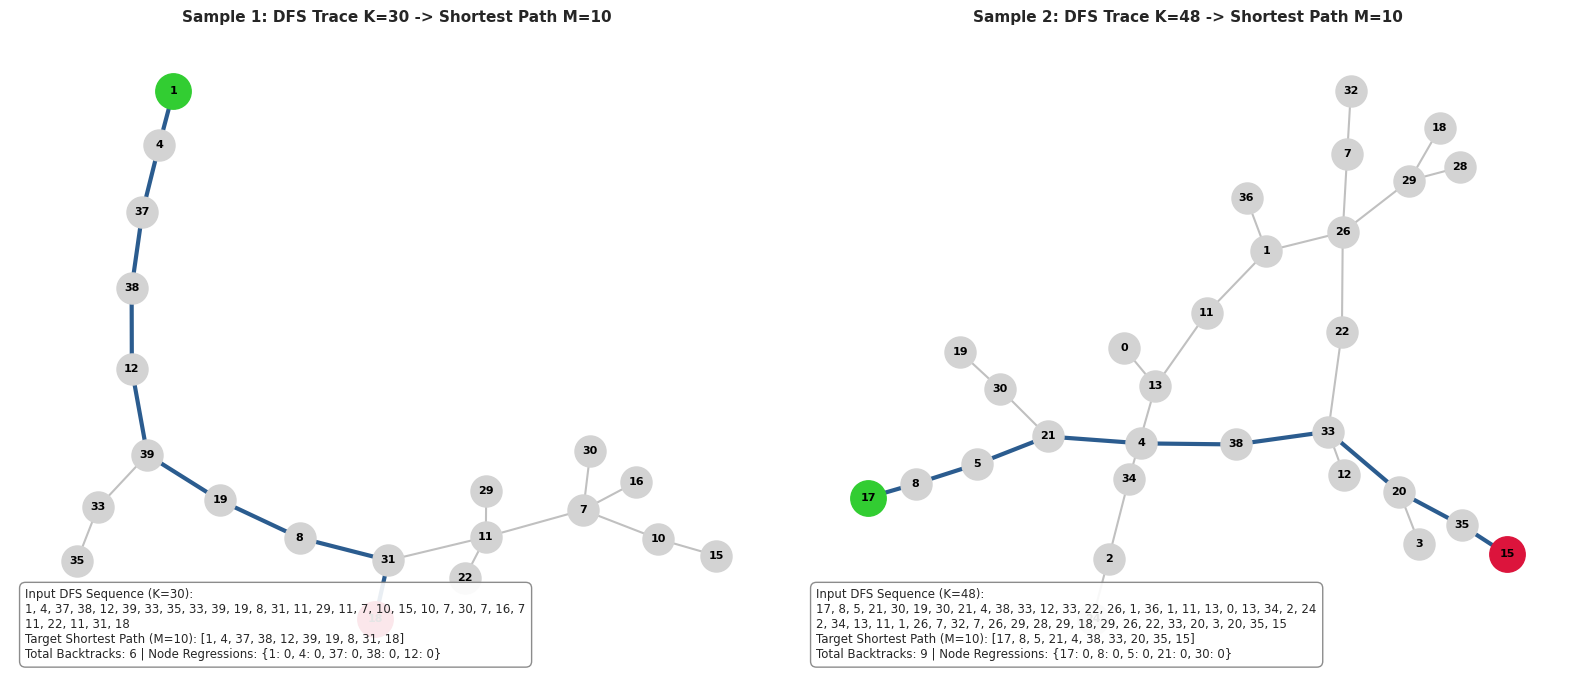

All publication-quality topology figures successfully generated and saved.


In [5]:
# Cell 5: Generate Publication-Quality Analytical Figures

sns.set_theme(style="whitegrid", palette="mako")

# Figure 1: Topology Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(degrees, discrete=True, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Node Degree Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Node Degree (k)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

sns.histplot(trace_lengths, discrete=True, kde=False, color='teal', ax=axes[1])
axes[1].set_title('DFS Trace Length (K) [30-50]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Trace Length (Tokens)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)

sns.histplot(sp_lengths, discrete=True, kde=False, color='darkblue', ax=axes[2])
axes[2].set_title('Shortest Path Length (M) [10-20]', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Path Length (Nodes)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)

plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/graph_topology_distributions.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/graph_topology_distributions.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/graph_topology_distributions.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/graph_topology_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Trace Compression & Backtracking Scatter Analysis
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(trace_lengths, sp_lengths, c=backtrack_counts, cmap='viridis', alpha=0.8, s=60, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Backtracks in Trace', fontsize=11, fontweight='bold')

ax.set_title('Hardened DFS Trace vs. Shortest Path Efficiency', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('DFS Traversal Trace Length (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Target Shortest Path Length (M)', fontsize=11, fontweight='bold')

plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/graph_dfs_compression_analysis.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/graph_dfs_compression_analysis.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/graph_dfs_compression_analysis.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/graph_dfs_compression_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Sample Graph Topology Layouts with Original Input Sequence Text and Visual Representation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i in range(2):
    trace_sample, sp_sample, G_sample, mapping_sample, backtracks_sample, node_backtracks_sample = raw_data[i]
    pos = nx.spring_layout(G_sample, seed=42+i)

    # Base graph
    nx.draw_networkx_nodes(G_sample, pos, ax=axes[i], node_color='lightgray', node_size=500)
    nx.draw_networkx_edges(G_sample, pos, ax=axes[i], edge_color='silver', width=1.5)

    # Highlight Shortest Path
    sp_edges = [(sp_sample[k], sp_sample[k+1]) for k in range(len(sp_sample)-1)]
    nx.draw_networkx_edges(G_sample, pos, ax=axes[i], edgelist=sp_edges, edge_color='#2b5c8f', width=3.0)

    # Start and Goal
    nx.draw_networkx_nodes(G_sample, pos, ax=axes[i], nodelist=[sp_sample[0]], node_color='limegreen', node_size=650)
    nx.draw_networkx_nodes(G_sample, pos, ax=axes[i], nodelist=[sp_sample[-1]], node_color='crimson', node_size=650)

    labels = {node: str(node) for node in G_sample.nodes()}
    nx.draw_networkx_labels(G_sample, pos, ax=axes[i], labels=labels, font_size=8, font_weight='bold')

    # Format original input sequence as text
    trace_text = f"Input DFS Sequence (K={len(trace_sample)}):\n" + ", ".join(map(str, trace_sample[:25])) + "\n" + ", ".join(map(str, trace_sample[25:]))
    sp_text = f"Target Shortest Path (M={len(sp_sample)}): {sp_sample}"
    backtrace_text = f"Total Backtracks: {backtracks_sample} | Node Regressions: {dict(list(node_backtracks_sample.items())[:5])}"

    # Text Box in Chart
    axes[i].text(0.02, 0.02, f"{trace_text}\n{sp_text}\n{backtrace_text}",
                 transform=axes[i].transAxes, fontsize=8.5, verticalalignment='bottom',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    axes[i].set_title(f"Sample {i+1}: DFS Trace K={len(trace_sample)} -> Shortest Path M={len(sp_sample)}", fontsize=11, fontweight='bold', pad=10)
    axes[i].axis('off')

plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/graph_sample_topologies.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/graph_sample_topologies.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/graph_sample_topologies.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/graph_sample_topologies.png", dpi=300, bbox_inches='tight')
plt.show()

print("All publication-quality topology figures successfully generated and saved.")


### Self-Reflection & Summary of Hardened Dataset Topology
1. **Hardened Traversal Trajectories**:
   The generated dataset containing 4,000 candidate-filtered graph DFS instances features sequence lengths bounded strictly to $30 \le K \le 50$ for input traces and $10 \le M \le 20$ for shortest paths.
2. **Node Backtraces & Induced Regressions**:
   We explicitly record backtrace counts and node-level induced regressions. This quantifies search difficulty and dead-end frequency across the traversal space.
3. **Reproducibility & Drive Checkpointing**:
   The dataset payload is serialized to `/content/drive/MyDrive/graph_data/graph_dfs_dataset.pt` with local fallback, providing a shared foundation for model training.
